In [ ]:
import pandas as pd
from models.regression.price_regression_models import (
    LinearRegressionPriceModel,
    RandomForestPriceModel,
    LightGBMPriceModel,
    XGBoostPriceModel,
    compare_regression_models,
)

df = pd.read_csv("Apart Deal_6.csv")

# 모델은 필요한만큼만 사용할 것(필요하지 않은 것은 지우거나 주석 처리)
models = [
    # LinearRegressionPriceModel(sample_size=100_000),
    RandomForestPriceModel(sample_size=100_000),
    # LightGBMPriceModel(sample_size=100_000),
    # XGBoostPriceModel(sample_size=100_000)
]

result_df = compare_regression_models(models, df)
result_df.to_csv("학습결과5.csv")

importance_df = models[0].get_feature_importance()
importance_df.to_csv("XGBoost_피처중요도.csv", index=False, encoding="utf-8-sig")

C:\Users\윤승혁\AppData\Local\Temp\ipykernel_22996\3920839014.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Apart Deal_6.csv")
100%|██████████| 1/1 [02:08<00:00, 128.69s/it]


In [2]:
importance_df["원본피처"] = importance_df["피처"].apply(
    lambda x: x.split("_")[0] if x.startswith("지역코드_") else x
)

grouped_importance_df = (
    importance_df
    .groupby("원본피처", as_index=False)["중요도"]
    .sum()
    .sort_values("중요도", ascending=False)
    .reset_index(drop=True)
)

grouped_importance_df.to_csv(
    "XGBoost_원본피처중요도.csv",
    index=False,
    encoding="utf-8-sig"
)

print(grouped_importance_df)

     원본피처       중요도
0    지역코드  0.973702
1    인근역수  0.007770
2    전용면적  0.004159
3    거래연도  0.003841
4     세대수  0.003490
5    건물연식  0.002429
6   브랜드여부  0.001762
7   인근학교수  0.001245
8       층  0.000635
9    기준금리  0.000624
10    거래월  0.000342


In [3]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

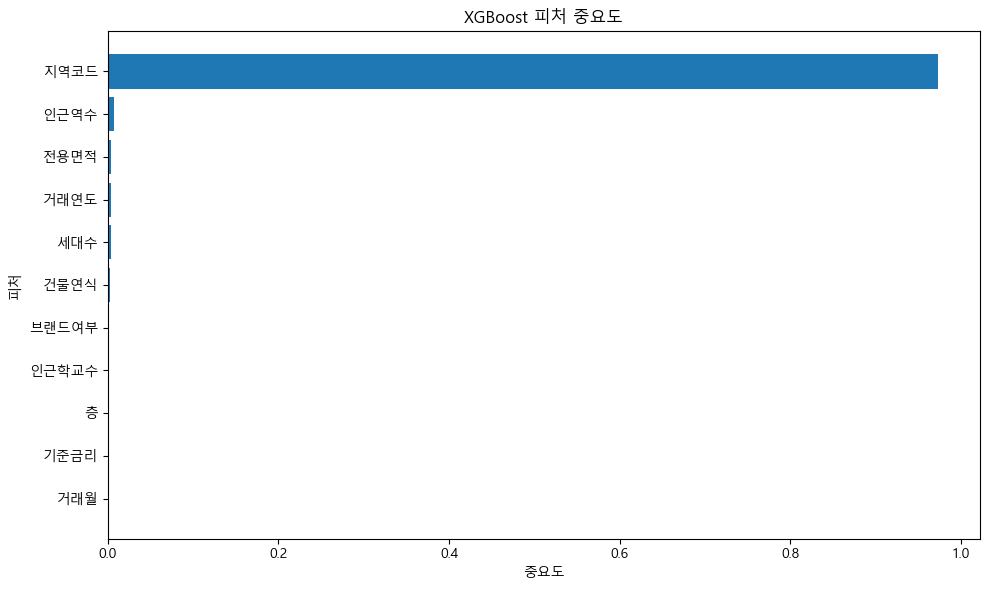

In [4]:
import matplotlib.pyplot as plt

# 중요도 기준 정렬
plot_df = grouped_importance_df.sort_values("중요도", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(grouped_importance_df["원본피처"], grouped_importance_df["중요도"])
plt.xlabel("중요도")
plt.ylabel("피처")
plt.title("XGBoost 피처 중요도")

plt.gca().invert_yaxis()  # 중요도 높은 피처를 위로 보냄

plt.tight_layout()
plt.show()